# **Chest X-Ray YOLO Model Training Example**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The focus of this notebook is solely on data loading and preliminary exploration.

# Clean environment

In [1]:
!rm -rf sample_data
# !rm -rf datasets/data

# Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [2]:
!pip install huggingface_hub pandas keras

# Getting the dataset

You can either use the complete dataset (more than 40 GB will be needed) or a 17 GB dataset created from the original that is stored on Google Drive and can be mounted in order to load it quickly.

**Important**: The download size of the complete dataset is around 40 GB.

In [3]:
import pandas as pd
import os
import zipfile
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from glob import glob
from itertools import chain
from matplotlib import pyplot as plt

In [4]:
HUGGING_FACE = "hugging_face"
GOOGLE_DRIVE = "google_drive"

# Modify this variable to change the dataset download mode
DATASET_DOWNLOAD_MODE = HUGGING_FACE

if DATASET_DOWNLOAD_MODE == HUGGING_FACE:
    from huggingface_hub import hf_hub_download

    REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
    FILEPATH = "data/Data_Entry_2017_v2020.csv"

    datasets_path = Path("datasets/").mkdir(exist_ok=True)
    dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

    # Download images
    for i in range(1, 12+1):
        FILEPATH = f"data/images/images_{i:03d}.zip"
        downloaded_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-downloaded.tmp"

        if downloaded_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            print(f"Downloading {FILEPATH}...")
            zip_path = Path(hf_hub_download(
                repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

            # Create a temp file that indicates the zip was completely downloaded
            downloaded_tmp_file.mkdir(parents=True, exist_ok=True)
            downloaded_tmp_file.touch()

        extracted_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-extracted.tmp"
        if extracted_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            zipfile.ZipFile(zip_path).extractall("datasets/data/")

            # Create a temp file that indicates the zip was completely extracted
            extracted_tmp_file.mkdir(parents=True, exist_ok=True)
            extracted_tmp_file.touch()

            os.system(f"rm datasets/{FILEPATH}")

            print("ZIP extracted and removed!")

    print("Dataset downloaded and extracted!")

# TODO: Implement Google Drive mount
# elif DATASET_DOWNLOAD_MODE == GOOGLE_DRIVE:
#     from google.colab import drive
#     drive.mount('/content/drive')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/images/images_001.zip already exists. Skipping download.
data/images/images_001.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/ima

# Data Exploration

In [5]:
# !ls datasets/data/images

## Clean and transform the data

In [6]:
csv = pd.read_csv(dataset_path)

# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

print(f'Found {len(images_paths)} images. Total Rows: {csv.shape[0]}')
csv['image_path'] = csv['Image Index'].map(images_paths.get)

# Remove rows that have a null path
csv.dropna(subset=['image_path'], inplace=True)
print(f"Dropped rows with a null path. {csv.shape[0]} rows remain.")

# Remove 'No Finding' labels from the Finding Labels column
csv['Finding Labels'] = csv['Finding Labels'].map(lambda x: x.replace('No Finding', ''))

# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))
# Remove empty string label
all_labels.remove('')

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

print(csv.sample(3))

print(
    '{} Labels\n{}'.format(
      len(all_labels),
      "\n".join([f"{label}: {int(csv[label].sum())}" for label in all_labels]),
    )
)

Found 56060 images. Total Rows: 112120
Dropped rows with a null path. 56060 rows remain.
            Image Index        Finding Labels  Follow-up #  Patient ID  \
72734  00017926_010.png  Atelectasis|Effusion           10       17926   
88729  00021984_000.png          Infiltration            0       21984   
43448  00011211_004.png                                  4       11211   

       Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
72734           61              M            AP                 2500     2048   
88729           26              M            PA                 2992     2991   
43448           73              M            AP                 2500     2048   

       OriginalImagePixelSpacing[x  ...  Edema Pleural_Thickening  Pneumonia  \
72734                        0.168  ...      0                  0          0   
88729                        0.143  ...      0                  0          0   
43448                        0.168  ...      0   

## Resampling the highly unbalanced dataset
Since the dataset is very unbalanced (there are WAY more healthy patients than patients with diseases, and some diseases are more common than others), we can resample it to be a more reasonable collection, so that the model doesn't pay more attention to the most common labels.

Weight is `0.04 + number of findings` for each label.

### Distribution before resampling

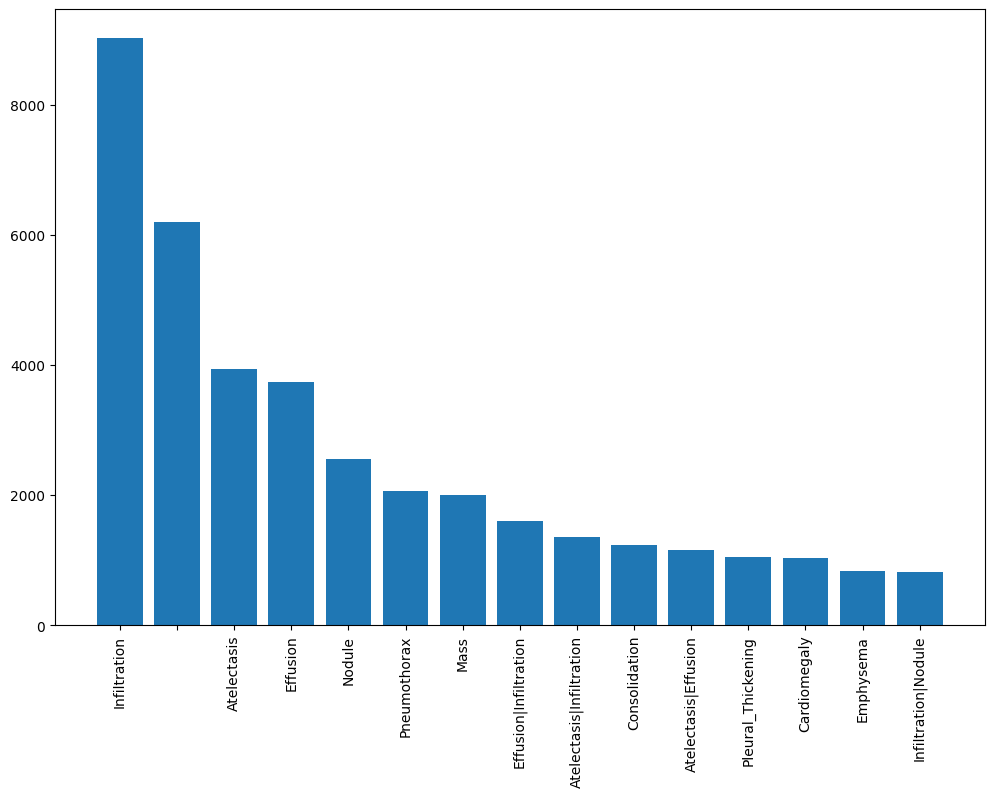

In [7]:
label_counts = csv['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

In [8]:
sample_weights = csv['Finding Labels'].map(
    lambda x: len(x.split('|')) if len(x)>0 else 0
).values + 4e-2
sample_weights /= sample_weights.sum()

# # If you want to see the weight of each row:
# for index, weight in enumerate(sample_weights):
#   print(f"Row {index}| Weight: {weight}")
# print(f"Length of sample weights: {len(sample_weights)}")
# print(f"Number of rows in dataset: {csv.shape[0]}")

sampled_df = csv.sample(csv.shape[0] // 2, weights=sample_weights)

### Distribution after resampling

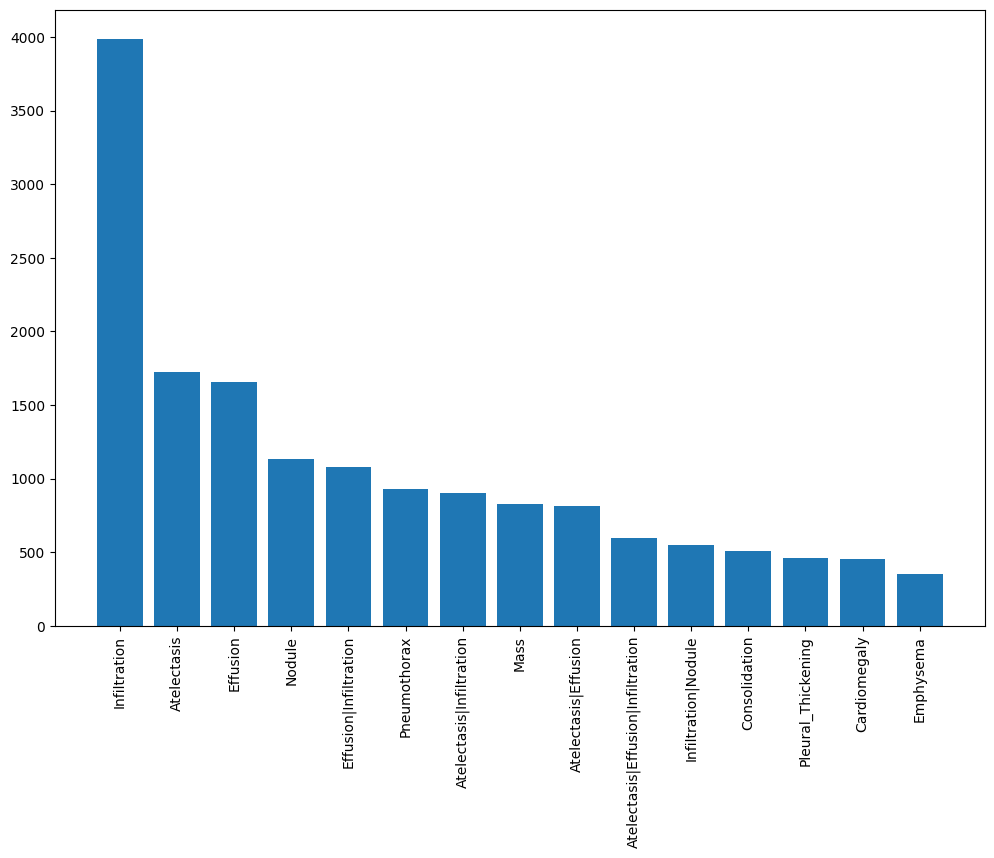

In [9]:
label_counts = sampled_df['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

### Delete images that are not in the dataframe returned from sampling

In [10]:
# Get images from the original dataframe that are not sampled
images_to_delete = csv[~csv["image_path"].isin(sampled_df["image_path"])]["image_path"].values

# Delete images
for image_path in tqdm(images_to_delete):
    if os.path.isfile(image_path):
        os.remove(image_path)

  0%|          | 0/28030 [00:00<?, ?it/s]

## Create a column containing the diseases as a list


In [11]:
sampled_df['disease_vec'] = sampled_df.apply(lambda x: x[all_labels].astype(int).values, axis=1)
print(sampled_df["disease_vec"])

11972     [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
92060     [1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0]
98000     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
109844    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
3341      [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
                             ...                    
41685     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
100409    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
74874     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
37135     [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
97457     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
Name: disease_vec, Length: 28030, dtype: object


## Split the dataset

In [12]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sampled_df,
                                   test_size = 0.15,
                                   random_state = 86196,
                                   stratify = sampled_df['Finding Labels'].map(lambda x: x[:4]))

train_df, validation_df = train_test_split(train_df,
                                   test_size = 0.10,
                                   random_state = 47941,
                                   stratify = train_df['Finding Labels'].map(lambda x: x[:4]))

print('Train:', train_df.shape[0], 'Validation:', validation_df.shape[0], 'Test:', test_df.shape[0])

Train: 21442 Validation: 2383 Test: 4205


## Get datasets of images

(1024, 1024, 3)


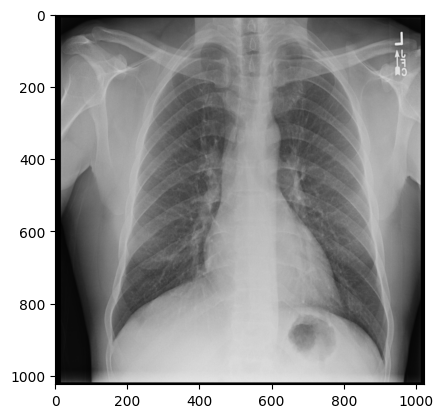

In [13]:
# Read an image using cv2
import cv2
img = cv2.imread(train_df["image_path"].iloc[0])

# Show using matplotlib
plt.imshow(img)

print(img.shape)

## Get datasets and augment data

In this step, we create datasets and apply data augmentations to improve model generalization. The augmentations include:

- Converting images to tensors with normalized pixel values.
- Random cropping (using 90% of the original image size) to add variation.
- Resizing to a fixed size of 640x640 for consistency.
- Random affine transformations (rotation and translation) to simulate different viewing angles (which are present in the original images).
- Applying Gaussian blur to mimic imaging noise.

In [14]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from PIL import Image

IMAGE_SIZE = (640, 640)
ORIGINAL_IMAGE_SIZE = np.array(cv2.imread(train_df["image_path"].iloc[0]).shape[:2])
CROP_IMAGE_SIZE = (ORIGINAL_IMAGE_SIZE * 0.9).astype(int)

transform = transforms.Compose([
    transforms.ToTensor(), # image values will be scaled between 0 and 1
    transforms.RandomCrop(size=CROP_IMAGE_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomAffine(degrees=15, translate=(0.075, 0.075)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
])

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, path_column, y_column, transform=None):
        self.dataframe = dataframe
        self.path_column = path_column
        self.y_column = y_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get the image path and label for the given index
        image_path = self.dataframe.iloc[index][self.path_column]
        label = self.dataframe.iloc[index][self.y_column]
        # Open image using PIL
        image = Image.open(image_path).convert("RGB")
        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

def get_images_dataset_from_dataframe(dataframe: pd.DataFrame,
                                      path_column: str, y_column: str,
                                      batch_size: int) -> DataLoader:
    dataset = ChestXRayDataset(dataframe, path_column, y_column, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    return loader

train_dataset = get_images_dataset_from_dataframe(
    train_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=16,
)

# TODO: Both validation and test datasets shouldn't be augmented
validation_dataset = get_images_dataset_from_dataframe(
    validation_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=32,
)
test_dataset = get_images_dataset_from_dataframe(
    test_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=64,
)


/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [35]:
import pickle
from pathlib import Path

# Save DataLoader objects as pickle files
SAVED_DATASETS_DIR = Path("saved_datasets")
SAVED_DATASETS_DIR.mkdir(parents=True, exist_ok=True)

with open(SAVED_DATASETS_DIR / "train_dataset.pkl", "wb") as f:
    pickle.dump(train_dataset, f)
with open(SAVED_DATASETS_DIR / "validation_dataset.pkl", "wb") as f:
    pickle.dump(validation_dataset, f)
with open(SAVED_DATASETS_DIR / "test_dataset.pkl", "wb") as f:
    pickle.dump(test_dataset, f)

# Save dataframe splits as CSV files
SAVED_DATAFRAMES_DIR = Path("saved_dataframes")
SAVED_DATAFRAMES_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SAVED_DATAFRAMES_DIR / "train_df.csv", index=False)
validation_df.to_csv(SAVED_DATAFRAMES_DIR / "validation_df.csv", index=False)
test_df.to_csv(SAVED_DATAFRAMES_DIR / "test_df.csv", index=False)

# Save the complete sampled dataframe
sampled_df.to_csv(SAVED_DATAFRAMES_DIR / "sampled_df.csv", index=False)

from google.colab import files
files.download(SAVED_DATAFRAMES_DIR / "train_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "validation_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "test_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "sampled_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualize the images from the datasets

In [ ]:
NUM_BATCHES_TO_SHOW = 2

for index, (images, labels) in enumerate(train_dataset):
    if index >= NUM_BATCHES_TO_SHOW:
        break
    print(f"*** BATCH {index+1} ***")
    for img, label in zip(images, labels):
        # Convert the one-hot label tensor to a list
        label = label.tolist()

        # Get all the Finding Labels corresponding to this image using one-hot encoding.
        finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
        if len(finding_labels) == 0:
            finding_labels = ["Healthy"]

        # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")

        plt.figure(figsize=(5,5))
        plt.imshow(img_np)
        plt.title(", ".join(finding_labels))
        plt.colorbar()
        plt.show()

    print("----------------------------------------------------------------\n" * 10)

# Get the fine-tuned model

# Create and train the fine-tuned model (option 1)

## Download the base model

In [16]:
def create_model_dirs():
    current_dir = Path.cwd()

    subdirs = [current_dir / name for name in ("saved_models",)]

    for subdir in subdirs:
        if not subdir.is_dir():
            print(f"Directory '{subdir}' not found. Creating it...")
            subdir.mkdir(parents=True)
            print(f"Created!")

    load_model_path.parent.mkdir(parents=True, exist_ok=True)

def download_model():
    from urllib.request import urlretrieve
    import zipfile
    import os
    from time import sleep

    url = "https://www.dropbox.com/scl/fi/jvgh2zh0nh0uc306ay3nc/yolo11m-seg.pt?rlkey=9ouh5cawxdf9qcdggpms30mc3&st=x54c05m2&dl=1"

    # download model from Dropbox
    try:
        urlretrieve(url, "saved_models/yolo11m-seg/model.pt")
    except Exception as e:
        print(f"Exception occurred: {e}.")
        if (Path.is_file(load_model_path)):
            print("Deleting partially downloaded file...")
            os.remove(load_model_path)

def setup():
    create_model_dirs()

    if not load_model_path.exists():
        print("Model not found. Downloading it...")
        download_model()
        print("Downloaded!")

def remove_setup():
    import shutil
    if model_base_dir.exists():
        shutil.rmtree(model_base_dir)
        print(f"Removed directory: {model_base_dir}")
    else:
        print(f"Directory {model_base_dir} does not exist. Nothing to remove.")

model_base_dir = Path.cwd() / "saved_models" / "yolo11m-seg"
load_model_path = model_base_dir / "model.pt"

# Uncomment to restart the setup
remove_setup()

setup()

Removed directory: /content/saved_models/yolo11m-seg
Model not found. Downloading it...
Downloaded!


## Load the base model

In [ ]:
from torch import load as torch_load, serialization
!pip install ultralytics

model = torch_load(load_model_path, weights_only=False)

## Train base model on the NIH Chest X-Ray dataset

In [18]:
import torch
import torch.nn as nn

import torch.nn as nn

class ClassificationWrapper(nn.Module):
    def __init__(self, segmentation_model, num_classes=14):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(144, num_classes)  # assumes the chosen output has 144 channels

    def forward(self, x):
        outputs = self.segmentation_model(x)

        if isinstance(outputs, (list, tuple)):
            out = outputs[0] # the first multi-scale output
            out = out[0] # the first channel (it's a gray image anyways)
        else:
            out = outputs
        # Apply adaptive pooling and flatten the features
        pooled = self.avgpool(out)  # shape: [B, 144, 1, 1]
        pooled = pooled.view(pooled.size(0), -1)  # shape: [B, 144]
        logits = self.fc(pooled)  # shape: [B, 14]
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

net = ClassificationWrapper(model['model']).to(device).float()

optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

# Training loss decreases only during the first two epochs
# Additional epochs provide negligible improvement
num_epochs = 2

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_dataset):
        images = images.to(device)
        labels = labels.to(device).float()  # multilabel targets as floats

        optimizer.zero_grad()
        outputs = net(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_dataset)}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {running_loss/len(train_dataset):.4f}")

fine_tuned_model = net

cuda
Epoch [1/5], Step [10/1341], Loss: 2.2434
Epoch [1/5], Step [20/1341], Loss: 1.8296
Epoch [1/5], Step [30/1341], Loss: 1.4724
Epoch [1/5], Step [40/1341], Loss: 1.2734
Epoch [1/5], Step [50/1341], Loss: 1.1470
Epoch [1/5], Step [60/1341], Loss: 0.8359
Epoch [1/5], Step [70/1341], Loss: 0.7219
Epoch [1/5], Step [80/1341], Loss: 0.5560
Epoch [1/5], Step [90/1341], Loss: 0.4479
Epoch [1/5], Step [100/1341], Loss: 0.2999
Epoch [1/5], Step [110/1341], Loss: 0.3561
Epoch [1/5], Step [120/1341], Loss: 0.3630
Epoch [1/5], Step [130/1341], Loss: 0.2842
Epoch [1/5], Step [140/1341], Loss: 0.3944
Epoch [1/5], Step [150/1341], Loss: 0.3199
Epoch [1/5], Step [160/1341], Loss: 0.3542
Epoch [1/5], Step [170/1341], Loss: 0.3851
Epoch [1/5], Step [180/1341], Loss: 0.3212
Epoch [1/5], Step [190/1341], Loss: 0.2759
Epoch [1/5], Step [200/1341], Loss: 0.3203
Epoch [1/5], Step [210/1341], Loss: 0.4313
Epoch [1/5], Step [220/1341], Loss: 0.4266
Epoch [1/5], Step [230/1341], Loss: 0.2779
Epoch [1/5], St

In [20]:
# Save the complete model
torch.save(net, model_base_dir / "model_classification_architecture.pt")
# Save the model state
torch.save(net.state_dict(), model_base_dir / "model_classification.pt")
# Save the model optimizer state
torch.save(optimizer.state_dict(), model_base_dir / "optimizer_classification.pt")
# Save the model training state
torch.save({"epoch": num_epochs, "loss": loss}, model_base_dir / "training_state_classification.pt")

In [26]:
# print(outputs[0].shape, "\n", outputs[1].shape, "\n", outputs[2].shape)
# print(labels.shape)
images.shape
# print(net)
# print(out.shape) # must make the out variable in forward() global

torch.Size([32, 3, 640, 640])

In [22]:
from google.colab import files
files.download('/content/saved_models/yolo11m-seg/model_classification.pt')
files.download('/content/saved_models/yolo11m-seg/model_classification_architecture.pt')
files.download('/content/saved_models/yolo11m-seg/optimizer_classification.pt')
files.download('/content/saved_models/yolo11m-seg/training_state_classification.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Load the fine-tuned model from Dropbox (option 2)

## Download the fine-tuned model

In [29]:
def create_model_dirs():
    current_dir = Path.cwd()

    subdirs = [current_dir / name for name in ("fine-tuned_models",)]

    for subdir in subdirs:
        if not subdir.is_dir():
            print(f"Directory '{subdir}' not found. Creating it...")
            subdir.mkdir(parents=True)
            print(f"Created!")

    load_model_path.parent.mkdir(parents=True, exist_ok=True)

def download_model():
    from urllib.request import urlretrieve
    import zipfile
    import os
    from time import sleep

    url = "https://www.dropbox.com/scl/fi/5c4m39bcq2x331xk03rho/model.pt?rlkey=dugi45dnd9mud32ie131rxxfv&st=9sa3rtg6&dl=1"

    # download model from Dropbox
    try:
        urlretrieve(url, "fine-tuned_models/yolo11m-seg/model.pt")
    except Exception as e:
        print(f"Exception occurred: {e}.")
        if (Path.is_file(load_model_path)):
            print("Deleting partially downloaded file...")
            os.remove(load_model_path)

def setup():
    create_model_dirs()

    if not load_model_path.exists():
        print("Model not found. Downloading it...")
        download_model()
        print("Downloaded!")

def remove_setup():
    import shutil
    if model_base_dir.exists():
        shutil.rmtree(model_base_dir)
        print(f"Removed directory: {model_base_dir}")
    else:
        print(f"Directory {model_base_dir} does not exist. Nothing to remove.")

model_base_dir = Path.cwd() / "fine-tuned_models" / "yolo11m-seg"
load_model_path = model_base_dir / "model.pt"

# Uncomment to restart the setup
remove_setup()

setup()

Directory /content/fine-tuned_models/yolo11m-seg does not exist. Nothing to remove.
Directory '/content/fine-tuned_models' not found. Creating it...
Created!
Model not found. Downloading it...
Downloaded!


## Load the fine-tuned model

In [ ]:
from torch import load as torch_load, serialization
!pip install ultralytics

fine_tuned_model = torch_load(load_model_path, weights_only=False)

# Inference

Probability of each label
Infiltration: 0.3967
Nodule: 0.1697
Atelectasis: 0.2447
Fibrosis: 0.0329
Edema: 0.0451
Pleural_Thickening: 0.0892
Pneumonia: 0.0364
Consolidation: 0.1160
Cardiomegaly: 0.0667
Effusion: 0.2615
Mass: 0.1145
Pneumothorax: 0.1078
Emphysema: 0.0413
Hernia: 0.0022
Predicted labels: ['Infiltration', 'Effusion']
Actual labels: ['Effusion']


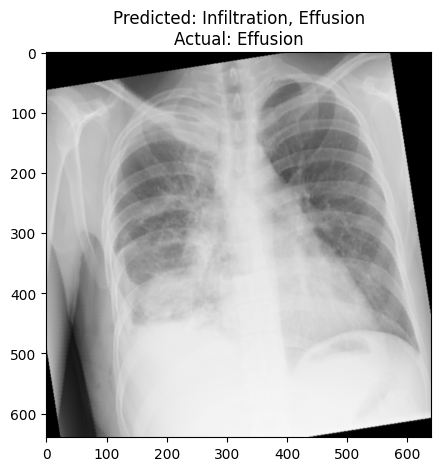

Probability of each label
Infiltration: 0.3972
Nodule: 0.1695
Atelectasis: 0.2451
Fibrosis: 0.0327
Edema: 0.0447
Pleural_Thickening: 0.0881
Pneumonia: 0.0361
Consolidation: 0.1156
Cardiomegaly: 0.0668
Effusion: 0.2607
Mass: 0.1130
Pneumothorax: 0.1063
Emphysema: 0.0404
Hernia: 0.0022
Predicted labels: ['Infiltration', 'Effusion']
Actual labels: ['Nodule', 'Fibrosis']


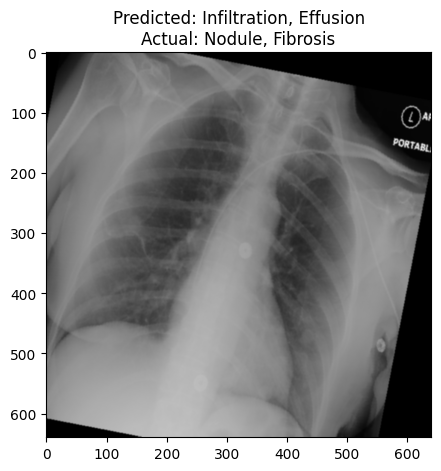

Probability of each label
Infiltration: 0.3980
Nodule: 0.1700
Atelectasis: 0.2450
Fibrosis: 0.0323
Edema: 0.0453
Pleural_Thickening: 0.0882
Pneumonia: 0.0357
Consolidation: 0.1159
Cardiomegaly: 0.0666
Effusion: 0.2610
Mass: 0.1121
Pneumothorax: 0.1065
Emphysema: 0.0401
Hernia: 0.0022
Predicted labels: ['Infiltration', 'Effusion']
Actual labels: ['Nodule']


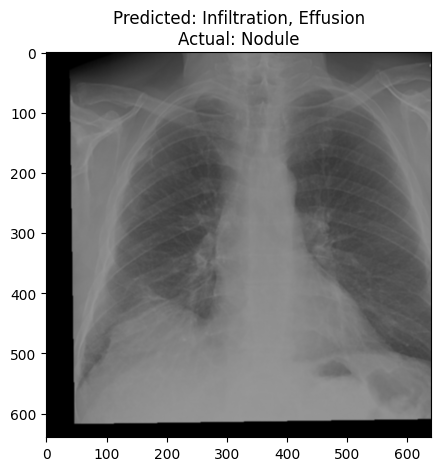

Probability of each label
Infiltration: 0.3967
Nodule: 0.1694
Atelectasis: 0.2452
Fibrosis: 0.0325
Edema: 0.0452
Pleural_Thickening: 0.0883
Pneumonia: 0.0361
Consolidation: 0.1160
Cardiomegaly: 0.0664
Effusion: 0.2606
Mass: 0.1130
Pneumothorax: 0.1064
Emphysema: 0.0407
Hernia: 0.0022
Predicted labels: ['Infiltration', 'Effusion']
Actual labels: ['Infiltration']


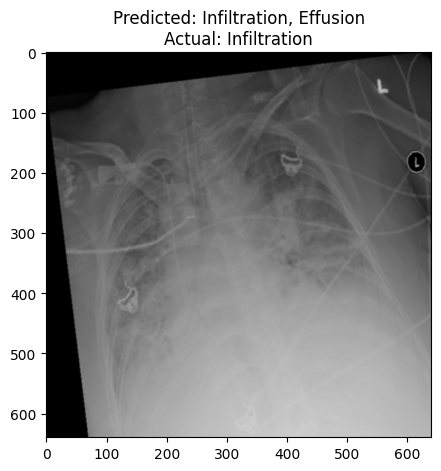

Probability of each label
Infiltration: 0.3973
Nodule: 0.1699
Atelectasis: 0.2451
Fibrosis: 0.0328
Edema: 0.0450
Pleural_Thickening: 0.0888
Pneumonia: 0.0361
Consolidation: 0.1159
Cardiomegaly: 0.0669
Effusion: 0.2603
Mass: 0.1129
Pneumothorax: 0.1067
Emphysema: 0.0406
Hernia: 0.0022
Predicted labels: ['Infiltration', 'Effusion']
Actual labels: ['Nodule']


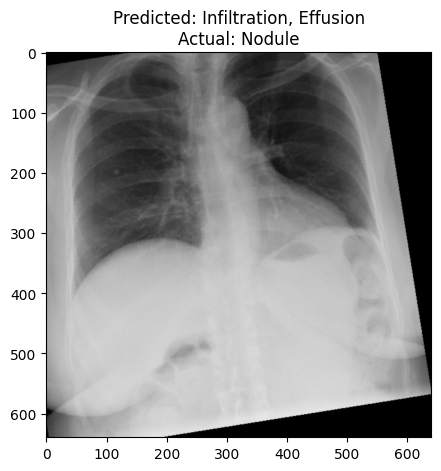

In [62]:
# Get the model inside the dictionary
fine_tuned_net = fine_tuned_model.to(device).float()

# # Set the network to evaluation mode

# with torch.no_grad():
#     # TODO: net.train() works fine, but with net.eval(),
#     # ValueError: Input dimension should be at least 3
#     # raises
#     for i, (images, labels) in enumerate(train_dataset):
#         images = images.to(device)
#         # show image 0
#         plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())
#         plt.show()

#         # image = images[0]
#         # print(image.shape)

#         outputs = net(images)
#         print(outputs)

# TODO: net.train() works fine, but with net.eval(),
fine_tuned_net.train()

# Get a single batch from the validation dataset and use the first image for inference
with torch.no_grad():
    num_predictions = 0
    for images, labels in validation_dataset:
        # Select the first image and add a batch dimension
        image = images[0].unsqueeze(0).to(device)

        # Do inference
        logits = fine_tuned_net(image)
        probs = torch.sigmoid(logits)

        print("Probability of each label")
        for label, prob in zip(all_labels, probs[0]):
            print(f"{label}: {prob.item():.4f}")

        # Apply a threshold to determine predicted labels
        pred_vector = (probs > 0.25).int().squeeze().tolist()
        if isinstance(pred_vector, int):
            pred_vector = [pred_vector]

        # Convert the predicted vector to corresponding disease names.
        predicted_labels = [all_labels[i] for i, flag in enumerate(pred_vector) if flag == 1]
        if not predicted_labels:
            predicted_labels = ["Healthy"]

        print("Predicted labels:", predicted_labels)

        # Ground truth
        actual_labels = [all_labels[i] for i, flag in enumerate(labels[0].tolist()) if flag == 1]
        if not actual_labels:
            actual_labels = ["Healthy"]

        print("Actual labels:", actual_labels)

        plt.figure(figsize=(5,5))
        plt.title(f"Predicted: {', '.join(predicted_labels)}\nActual: {', '.join(actual_labels)}")
        plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())
        plt.show()

        num_predictions += 1

        if num_predictions >= 5:
            break

# What's next

* The model is currently predicting every image as Healthy with a threshold of 0.5. Maybe the 0.5 threshold is too high or there's something wrong in the training, causing the probability assigned to each class to be too low. Might also try implementing weighted losses.
* With a threshold of 0.25, the model predicts all images as Infiltration and Effusion. Might be a sign of imbalance. Weighted losses might help.
* The way the wrapper was made for the PyTorch model is a mess.
* The net should be in eval() mode.
* Implement a visualization of the segmentation made by the model on the images.
* Currently, it seems like the whole neural network is being trained instead of just the last layers. Instead of a fine-tuning, a complete retraining is being made. That might be why the 5 epochs took around 90 minutes using a Google Colab instance with a GPU. Only the last layers should be modified during the training and the rest should be freezed.